#  **Case Study:  How Does a Bike-Share Navigate Speedy Success?**

## This is a case study of a fictional company, Cyclistic.

I work as a junior data analyst working in the marketing analyst team at Cyclistic, a bike-share company in Chicago. The director of marketing believes the company’s future success depends on maximizing the number of annual memberships. Therefore,
my team wants to understand how casual riders and annual members use Cyclistic bikes differently. 

From these insights, my team will design a new marketing strategy to convert casual riders into annual members. But first, Cyclistic executives
must approve my recommendations, so they must be backed up with compelling data insights and professional data
visualizations.

My data analysis followed the **Ask, Prepare, Process, Analyze, Share** and **Act** process, 

However, my notebook begins with the **Share**, followed by **Act** phase.


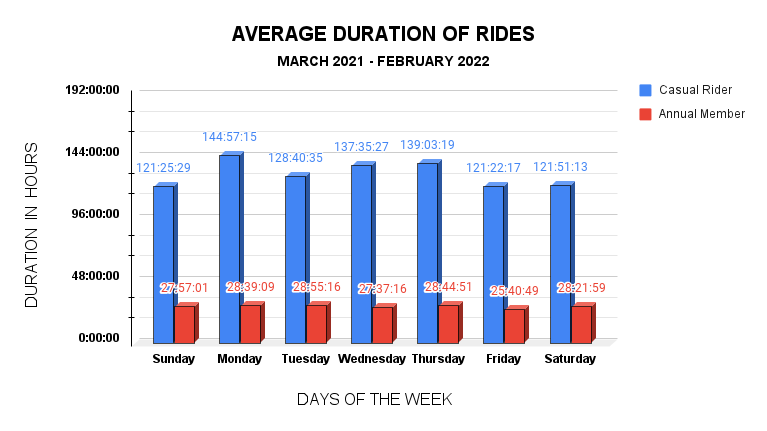

# SHARE Phase: KEY FINDINGS

1. On average, casual riders use the bike service more than members
2. On average, casual riders had the highest patronage on Mondays
3. On average, casual riders had the least patronage on Fridays.
4. On average, annual members had the highest patronage on Tuesday, although not very significantly different from the other days
5. On average, annual members had the least patronage on Fridays, although not very significantly different from the other days

# ACT Phase: RECOMMENDATIONS
1. Marketing campaigns can be targeted at offering annual membership discounts to casual riders who patronize the service for Monday trips
2. A further analysis be done on why casual riders patronize the service most on Mondays
3. A further analysis be done on the effects of COVID and lockdown restrictions on commutes within Chicago between March 2021 and February 2022


# ASK Phase

**Business Task**: Data that shows how annual members and casual riders use Cyclistic bikes differently

**Stakeholders:** 
1. Cyclistic marketing analytics team
2. My manager, Moreno
3. Cyclistic management team

# PREPARE Phase

**Data Source**: 12 months of trip data from March, 2021 - February, 2022 was used for this analysis.
https://divvy-tripdata.s3.amazonaws.com/index.html

**Data Licence**: https://ride.divvybikes.com/data-license-agreement


# PROCESS Phase

**Install packages**
* tidyverse for data import and wrangling
* lubridate for date functions
* ggplot for visualization

In [1]:
# This R environment comes with many helpful analytics packages installed
# It is defined by the kaggle/rstats Docker image: https://github.com/kaggle/docker-rstats
# For example, here's a helpful package to load

library(tidyverse) # metapackage of all tidyverse packages
library(lubridate)  #helps wrangle date attributes
library(ggplot2)  #helps visualize data

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

list.files(path = "../input")

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session



── Attaching packages ─────────────────────────────────────── tidyverse 1.3.1 ──

✔ ggplot2 3.3.5     ✔ purrr   0.3.4
✔ tibble  3.1.5     ✔ dplyr   1.0.7
✔ tidyr   1.1.4     ✔ stringr 1.4.0
✔ readr   2.0.2     ✔ forcats 0.5.1

── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()


Attaching package: ‘lubridate’


The following objects are masked from ‘package:base’:

    date, intersect, setdiff, union




[1] "divvy-bikeshare-data"

##=====================
STEP 1: COLLECT DATA
##=====================

In [2]:

# Upload Divvy datasets (csv files) here
X202103_divvy_tripdata <- read_csv("../input/divvy-bikeshare-data/202103-divvy-tripdata.csv")
X202104_divvy_tripdata <- read_csv("../input/divvy-bikeshare-data/202104-divvy-tripdata.csv")
X202105_divvy_tripdata <- read_csv("../input/divvy-bikeshare-data/202105-divvy-tripdata.csv")
X202106_divvy_tripdata <- read_csv("../input/divvy-bikeshare-data/202106-divvy-tripdata.csv")
X202107_divvy_tripdata <- read_csv("../input/divvy-bikeshare-data/202107-divvy-tripdata.csv")
X202108_divvy_tripdata <- read_csv("../input/divvy-bikeshare-data/202108-divvy-tripdata.csv")
X202109_divvy_tripdata <- read_csv("../input/divvy-bikeshare-data/202109-divvy-tripdata.csv")
X202110_divvy_tripdata <- read_csv("../input/divvy-bikeshare-data/202110-divvy-tripdata.csv")
X202111_divvy_tripdata <- read_csv("../input/divvy-bikeshare-data/202111-divvy-tripdata.csv")
X202112_divvy_tripdata <- read_csv("../input/divvy-bikeshare-data/202112-divvy-tripdata.csv")
X202201_divvy_tripdata <- read_csv("../input/divvy-bikeshare-data/202201-divvy-tripdata.csv")
X202202_divvy_tripdata <- read_csv("../input/divvy-bikeshare-data/202202-divvy-tripdata.csv")



Rows: 228496 Columns: 13

── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (9): ride_id, rideable_type, started_at, ended_at, start_station_name, s...
dbl (4): start_lat, start_lng, end_lat, end_lng


ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.

Rows: 337230 Columns: 13

── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (9): ride_id, rideable_type, started_at, ended_at, start_station_name, s...
dbl (4): start_lat, start_lng, end_lat, end_lng


ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.

Rows: 531633 Columns: 13

── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (9): ride_id, rideable_type, started_at, ended_at, start_sta

##====================
STEP 2: WRANGLE DATA AND COMBINE INTO A SINGLE FILE
##=====================



In [3]:

# Compare column names for each of the files
colnames(X202103_divvy_tripdata)
colnames(X202104_divvy_tripdata)
colnames(X202105_divvy_tripdata)
colnames(X202106_divvy_tripdata)
colnames(X202107_divvy_tripdata)
colnames(X202108_divvy_tripdata)
colnames(X202109_divvy_tripdata)
colnames(X202110_divvy_tripdata)
colnames(X202111_divvy_tripdata)
colnames(X202112_divvy_tripdata)
colnames(X202201_divvy_tripdata)
colnames(X202202_divvy_tripdata)


[1] "ride_id"            "rideable_type"      "started_at"        
 [4] "ended_at"           "start_station_name" "start_station_id"  
 [7] "end_station_name"   "end_station_id"     "start_lat"         
[10] "start_lng"          "end_lat"            "end_lng"           
[13] "member_casual"

[1] "ride_id"            "rideable_type"      "started_at"        
 [4] "ended_at"           "start_station_name" "start_station_id"  
 [7] "end_station_name"   "end_station_id"     "start_lat"         
[10] "start_lng"          "end_lat"            "end_lng"           
[13] "member_casual"

[1] "ride_id"            "rideable_type"      "started_at"        
 [4] "ended_at"           "start_station_name" "start_station_id"  
 [7] "end_station_name"   "end_station_id"     "start_lat"         
[10] "start_lng"          "end_lat"            "end_lng"           
[13] "member_casual"

[1] "ride_id"            "rideable_type"      "started_at"        
 [4] "ended_at"           "start_station_name" "start_station_id"  
 [7] "end_station_name"   "end_station_id"     "start_lat"         
[10] "start_lng"          "end_lat"            "end_lng"           
[13] "member_casual"

[1] "ride_id"            "rideable_type"      "started_at"        
 [4] "ended_at"           "start_station_name" "start_station_id"  
 [7] "end_station_name"   "end_station_id"     "start_lat"         
[10] "start_lng"          "end_lat"            "end_lng"           
[13] "member_casual"

...

[1] "ride_id"            "rideable_type"      "started_at"        
 [4] "ended_at"           "start_station_name" "start_station_id"  
 [7] "end_station_name"   "end_station_id"     "start_lat"         
[10] "start_lng"          "end_lat"            "end_lng"           
[13] "member_casual"

[1] "ride_id"            "rideable_type"      "started_at"        
 [4] "ended_at"           "start_station_name" "start_station_id"  
 [7] "end_station_name"   "end_station_id"     "start_lat"         
[10] "start_lng"          "end_lat"            "end_lng"           
[13] "member_casual"

[1] "ride_id"            "rideable_type"      "started_at"        
 [4] "ended_at"           "start_station_name" "start_station_id"  
 [7] "end_station_name"   "end_station_id"     "start_lat"         
[10] "start_lng"          "end_lat"            "end_lng"           
[13] "member_casual"

[1] "ride_id"            "rideable_type"      "started_at"        
 [4] "ended_at"           "start_station_name" "start_station_id"  
 [7] "end_station_name"   "end_station_id"     "start_lat"         
[10] "start_lng"          "end_lat"            "end_lng"           
[13] "member_casual"

[1] "ride_id"            "rideable_type"      "started_at"        
 [4] "ended_at"           "start_station_name" "start_station_id"  
 [7] "end_station_name"   "end_station_id"     "start_lat"         
[10] "start_lng"          "end_lat"            "end_lng"           
[13] "member_casual"

In [4]:
# Inspect the dataframes and look for incongruencies
str(X202103_divvy_tripdata)
str(X202104_divvy_tripdata)
str(X202105_divvy_tripdata)
str(X202106_divvy_tripdata)
str(X202107_divvy_tripdata)
str(X202108_divvy_tripdata)
str(X202109_divvy_tripdata)
str(X202110_divvy_tripdata)
str(X202111_divvy_tripdata)
str(X202112_divvy_tripdata)
str(X202201_divvy_tripdata)
str(X202202_divvy_tripdata)



spec_tbl_df [228,496 × 13] (S3: spec_tbl_df/tbl_df/tbl/data.frame)
 $ ride_id           : chr [1:228496] "CFA86D4455AA1030" "30D9DC61227D1AF3" "846D87A15682A284" "994D05AA75A168F2" ...
 $ rideable_type     : chr [1:228496] "classic_bike" "classic_bike" "classic_bike" "classic_bike" ...
 $ started_at        : chr [1:228496] "16/03/2021 8:32" "28/03/2021 1:26" "11/03/2021 21:17" "11/03/2021 13:26" ...
 $ ended_at          : chr [1:228496] "16/03/2021 8:36" "28/03/2021 1:36" "11/03/2021 21:33" "11/03/2021 13:55" ...
 $ start_station_name: chr [1:228496] "Humboldt Blvd & Armitage Ave" "Humboldt Blvd & Armitage Ave" "Shields Ave & 28th Pl" "Winthrop Ave & Lawrence Ave" ...
 $ start_station_id  : chr [1:228496] "15651" "15651" "15443" "TA1308000021" ...
 $ end_station_name  : chr [1:228496] "Stave St & Armitage Ave" "Central Park Ave & Bloomingdale Ave" "Halsted St & 35th St" "Broadway & Sheridan Rd" ...
 $ end_station_id    : chr [1:228496] "13266" "18017" "TA1308000043" "13323" ...
 $ star

Next, Convert ride_id and rideable_type to character so that they can stack correctly.
* *They are automatically recognized as characters though*

In [5]:

X202103_divvy_tripdata <-  mutate(X202103_divvy_tripdata, ride_id = as.character(ride_id)
                   ,rideable_type = as.character(rideable_type)) 

X202104_divvy_tripdata <-  mutate(X202104_divvy_tripdata, ride_id = as.character(ride_id)
                                  ,rideable_type = as.character(rideable_type)) 

X202105_divvy_tripdata <-  mutate(X202105_divvy_tripdata, ride_id = as.character(ride_id)
                                  ,rideable_type = as.character(rideable_type)) 

X202106_divvy_tripdata <-  mutate(X202106_divvy_tripdata, ride_id = as.character(ride_id)
                                  ,rideable_type = as.character(rideable_type)) 

X202107_divvy_tripdata <-  mutate(X202107_divvy_tripdata, ride_id = as.character(ride_id)
                                  ,rideable_type = as.character(rideable_type)) 

X202108_divvy_tripdata <-  mutate(X202108_divvy_tripdata, ride_id = as.character(ride_id)
                                  ,rideable_type = as.character(rideable_type)) 

X202109_divvy_tripdata <-  mutate(X202109_divvy_tripdata, ride_id = as.character(ride_id)
                                  ,rideable_type = as.character(rideable_type)) 

X202110_divvy_tripdata <-  mutate(X202110_divvy_tripdata, ride_id = as.character(ride_id)
                                  ,rideable_type = as.character(rideable_type)) 

X202111_divvy_tripdata <-  mutate(X202111_divvy_tripdata, ride_id = as.character(ride_id)
                                  ,rideable_type = as.character(rideable_type)) 

X202112_divvy_tripdata <-  mutate(X202112_divvy_tripdata, ride_id = as.character(ride_id)
                                  ,rideable_type = as.character(rideable_type)) 

X202201_divvy_tripdata <-  mutate(X202201_divvy_tripdata, ride_id = as.character(ride_id)
                                  ,rideable_type = as.character(rideable_type)) 

X202202_divvy_tripdata <-  mutate(X202202_divvy_tripdata, ride_id = as.character(ride_id)
                                  ,rideable_type = as.character(rideable_type)) 





Now, merge the 12 files into 1 dataframe

In [6]:

all_trips <- bind_rows(X202103_divvy_tripdata, X202104_divvy_tripdata, 
                       X202105_divvy_tripdata, X202106_divvy_tripdata, 
                       X202107_divvy_tripdata, X202108_divvy_tripdata, 
                       X202109_divvy_tripdata, X202110_divvy_tripdata, 
                       X202111_divvy_tripdata, X202112_divvy_tripdata, 
                       X202201_divvy_tripdata, X202202_divvy_tripdata )

Next, remove latitude and longitude data.
* *This data will not be used in our analysis.*

In [7]:

all_trips <- all_trips %>%
  select(-c(start_lat, start_lng, end_lat, end_lng))



##=====================
STEP 3: CLEAN UP AND ADD DATA TO PREPARE FOR ANALYSIS
##=====================

In [8]:

# Inspect the new table that has been created
colnames(all_trips)  #List of column names
nrow(all_trips)  #How many rows are in data frame?
dim(all_trips)  #Dimensions of the data frame?
head(all_trips)  #See the first 6 rows of data frame.  Also tail(all_trips)
str(all_trips)  #See list of columns and data types (numeric, character, etc)
summary(all_trips)  #Statistical summary of data. Mainly for numerics



[1] "ride_id"            "rideable_type"      "started_at"        
[4] "ended_at"           "start_station_name" "start_station_id"  
[7] "end_station_name"   "end_station_id"     "member_casual"

[1] 5667986

[1] 5667986       9

ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,member_casual
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
CFA86D4455AA1030,classic_bike,16/03/2021 8:32,16/03/2021 8:36,Humboldt Blvd & Armitage Ave,15651,Stave St & Armitage Ave,13266,casual
30D9DC61227D1AF3,classic_bike,28/03/2021 1:26,28/03/2021 1:36,Humboldt Blvd & Armitage Ave,15651,Central Park Ave & Bloomingdale Ave,18017,casual
846D87A15682A284,classic_bike,11/03/2021 21:17,11/03/2021 21:33,Shields Ave & 28th Pl,15443,Halsted St & 35th St,TA1308000043,casual
994D05AA75A168F2,classic_bike,11/03/2021 13:26,11/03/2021 13:55,Winthrop Ave & Lawrence Ave,TA1308000021,Broadway & Sheridan Rd,13323,casual
DF7464FBE92D8308,classic_bike,21/03/2021 9:09,21/03/2021 9:27,Glenwood Ave & Touhy Ave,525,Chicago Ave & Sheridan Rd,E008,casual
CEBA8516FD17F8D8,classic_bike,20/03/2021 11:08,20/03/2021 11:29,Glenwood Ave & Touhy Ave,525,Chicago Ave & Sheridan Rd,E008,casual


tibble [5,667,986 × 9] (S3: tbl_df/tbl/data.frame)
 $ ride_id           : chr [1:5667986] "CFA86D4455AA1030" "30D9DC61227D1AF3" "846D87A15682A284" "994D05AA75A168F2" ...
 $ rideable_type     : chr [1:5667986] "classic_bike" "classic_bike" "classic_bike" "classic_bike" ...
 $ started_at        : chr [1:5667986] "16/03/2021 8:32" "28/03/2021 1:26" "11/03/2021 21:17" "11/03/2021 13:26" ...
 $ ended_at          : chr [1:5667986] "16/03/2021 8:36" "28/03/2021 1:36" "11/03/2021 21:33" "11/03/2021 13:55" ...
 $ start_station_name: chr [1:5667986] "Humboldt Blvd & Armitage Ave" "Humboldt Blvd & Armitage Ave" "Shields Ave & 28th Pl" "Winthrop Ave & Lawrence Ave" ...
 $ start_station_id  : chr [1:5667986] "15651" "15651" "15443" "TA1308000021" ...
 $ end_station_name  : chr [1:5667986] "Stave St & Armitage Ave" "Central Park Ave & Bloomingdale Ave" "Halsted St & 35th St" "Broadway & Sheridan Rd" ...
 $ end_station_id    : chr [1:5667986] "13266" "18017" "TA1308000043" "13323" ...
 $ member_casua

   ride_id          rideable_type       started_at          ended_at        
 Length:5667986     Length:5667986     Length:5667986     Length:5667986    
 Class :character   Class :character   Class :character   Class :character  
 Mode  :character   Mode  :character   Mode  :character   Mode  :character  
 start_station_name start_station_id   end_station_name   end_station_id    
 Length:5667986     Length:5667986     Length:5667986     Length:5667986    
 Class :character   Class :character   Class :character   Class :character  
 Mode  :character   Mode  :character   Mode  :character   Mode  :character  
 member_casual     
 Length:5667986    
 Class :character  
 Mode  :character  

There are a few problems we will need to fix:
* (1) In the "member_casual" column, there are two names for members ("member" and "Subscriber") and two names for casual riders ("Customer" and "casual"). We will need to consolidate that from four to two labels.
* (2) The data can only be aggregated at the ride-level, which is too granular. We will want to add some additional columns of data -- such as day, month, year -- that provide additional opportunities to aggregate the data.
* (3) We will want to add a calculated field for length of ride since the 2020Q1 data did not have the "tripduration" column. We will add "ride_length" to the entire dataframe for consistency.
* (4) There are some rides where tripduration shows up as negative, including several hundred rides where Divvy took bikes out of circulation for Quality Control reasons. We will want to delete these rides.


 In the "member_casual" column, replace "Subscriber" with "member" and "Customer" with "casual"
Before 2020, Divvy used different labels for these two types of riders ... we will want to make our dataframe consistent with their current nomenclature

*N.B.: "Level" is a special property of a column that is retained even if a subset does not contain any values from a specific level*

Begin by seeing how many observations fall under each usertype

In [9]:
table(all_trips$member_casual)


 casual  member 
2540693 3127293 

Reassign to the desired values 

In [10]:
all_trips <-  all_trips %>% 
  mutate(member_casual = recode(member_casual
                                ,"Subscriber" = "member"
                                ,"Customer" = "casual"))

Check to make sure the proper number of observations were reassigned

In [11]:
table(all_trips$member_casual)


 casual  member 
2540693 3127293 

 Add columns that list the date, month, day, and year of each ride
This will allow us to aggregate ride data for each month, day, or year ... before completing these operations we could only aggregate at the ride level
https://www.statmethods.net/input/dates.html more on date formats in R found at that link

In [12]:
all_trips$date <- as.Date(all_trips$started_at) #The default format is yyyy-mm-dd
all_trips$month <- format(as.Date(all_trips$date), "%m")
all_trips$day <- format(as.Date(all_trips$date), "%d")
all_trips$year <- format(as.Date(all_trips$date), "%Y")
all_trips$day_of_week <- format(as.Date(all_trips$date), "%A")

Add a "ride_length" calculation to all_trips (in seconds)

In [13]:
all_trips$ride_length <- difftime(all_trips$ended_at,all_trips$started_at)

Inspect the structure of the columns

In [14]:
str(all_trips)

tibble [5,667,986 × 15] (S3: tbl_df/tbl/data.frame)
 $ ride_id           : chr [1:5667986] "CFA86D4455AA1030" "30D9DC61227D1AF3" "846D87A15682A284" "994D05AA75A168F2" ...
 $ rideable_type     : chr [1:5667986] "classic_bike" "classic_bike" "classic_bike" "classic_bike" ...
 $ started_at        : chr [1:5667986] "16/03/2021 8:32" "28/03/2021 1:26" "11/03/2021 21:17" "11/03/2021 13:26" ...
 $ ended_at          : chr [1:5667986] "16/03/2021 8:36" "28/03/2021 1:36" "11/03/2021 21:33" "11/03/2021 13:55" ...
 $ start_station_name: chr [1:5667986] "Humboldt Blvd & Armitage Ave" "Humboldt Blvd & Armitage Ave" "Shields Ave & 28th Pl" "Winthrop Ave & Lawrence Ave" ...
 $ start_station_id  : chr [1:5667986] "15651" "15651" "15443" "TA1308000021" ...
 $ end_station_name  : chr [1:5667986] "Stave St & Armitage Ave" "Central Park Ave & Bloomingdale Ave" "Halsted St & 35th St" "Broadway & Sheridan Rd" ...
 $ end_station_id    : chr [1:5667986] "13266" "18017" "TA1308000043" "13323" ...
 $ member_casu

Convert "ride_length" from Factor to numeric so we can run calculations on the data

In [15]:
is.factor(all_trips$ride_length)
all_trips$ride_length <- as.numeric(as.character(all_trips$ride_length))
is.numeric(all_trips$ride_length)




[1] FALSE

[1] TRUE

Remove "bad" data:
The dataframe includes a few hundred entries when bikes were taken out of docks and checked for quality by Divvy or ride_length was negative
We will create a new version of the dataframe (v2) since data is being removed


In [16]:

all_trips_v2 <- all_trips[!(all_trips$start_station_name == "HQ QR" | all_trips$ride_length<0),]

# ANALYZE Phase

##=====================
STEP 4: CONDUCT DESCRIPTIVE ANALYSIS
##=====================

Descriptive analysis on ride_length (all figures in seconds)

In [17]:

mean(all_trips_v2$ride_length) #straight average (total ride length / rides)
median(all_trips_v2$ride_length) #midpoint number in the ascending array of ride lengths
max(all_trips_v2$ride_length) #longest ride
min(all_trips_v2$ride_length) #shortest ride


[1] NA

[1] NA

[1] NA

[1] NA

You can condense the four lines above to one line using summary() on the specific attribute

In [18]:
summary(all_trips_v2$ride_length)

     Min.   1st Qu.    Median      Mean   3rd Qu.      Max.      NA's 
        0         0         0    266362         0 915148800    712864 

Compare members and casual users

In [19]:
aggregate(all_trips_v2$ride_length ~ all_trips_v2$member_casual, FUN = mean)
aggregate(all_trips_v2$ride_length ~ all_trips_v2$member_casual, FUN = median)
aggregate(all_trips_v2$ride_length ~ all_trips_v2$member_casual, FUN = max)
aggregate(all_trips_v2$ride_length ~ all_trips_v2$member_casual, FUN = min)

all_trips_v2$member_casual,all_trips_v2$ride_length
<chr>,<dbl>
casual,470772.7
member,100751.1


all_trips_v2$member_casual,all_trips_v2$ride_length
<chr>,<dbl>
casual,0
member,0


all_trips_v2$member_casual,all_trips_v2$ride_length
<chr>,<dbl>
casual,915148800
member,63158400


all_trips_v2$member_casual,all_trips_v2$ride_length
<chr>,<dbl>
casual,0
member,0


See the average ride time by each day for members vs casual users

In [20]:
aggregate(all_trips_v2$ride_length ~ all_trips_v2$member_casual + all_trips_v2$day_of_week, FUN = mean)

all_trips_v2$member_casual,all_trips_v2$day_of_week,all_trips_v2$ride_length
<chr>,<chr>,<dbl>
casual,Friday,436937.48
member,Friday,92449.31
casual,Monday,521835.02
member,Monday,103148.99
casual,Saturday,438673.39
member,Saturday,102119.32
casual,Sunday,437128.96
member,Sunday,100620.88
casual,Thursday,500599.25


Notice that the days of the week are out of order. Let's fix that.

In [21]:
all_trips_v2$day_of_week <- ordered(all_trips_v2$day_of_week, levels=c("Sunday", "Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday"))


Now, let's run the average ride time by each day for members vs casual users


In [22]:
aggregate(all_trips_v2$ride_length ~ all_trips_v2$member_casual + all_trips_v2$day_of_week, FUN = mean)


all_trips_v2$member_casual,all_trips_v2$day_of_week,all_trips_v2$ride_length
<chr>,<ord>,<dbl>
casual,Sunday,437128.96
member,Sunday,100620.88
casual,Monday,521835.02
member,Monday,103148.99
casual,Tuesday,463235.47
member,Tuesday,104115.72
casual,Wednesday,495326.62
member,Wednesday,99436.10
casual,Thursday,500599.25


Analyze ridership data by type and weekday

In [23]:
all_trips_v2 %>% 
  mutate(weekday = wday(started_at, label = TRUE)) %>%  #creates weekday field using wday()
  group_by(member_casual, weekday) %>%  #groups by usertype and weekday
  summarise(number_of_rides = n()							#calculates the number of rides and average duration 
            ,average_duration = mean(ride_length)) %>% 		# calculates the average duration
  arrange(member_casual, weekday)								# sorts


`summarise()` has grouped output by 'member_casual'. You can override using the `.groups` argument.



member_casual,weekday,number_of_rides,average_duration
<chr>,<ord>,<int>,<dbl>
casual,Sun,327123,437128.96
casual,Mon,330808,521835.02
casual,Tue,321599,463235.47
casual,Wed,305299,495326.62
casual,Thu,315070,500599.25
casual,Fri,313421,436937.48
casual,Sat,303787,438673.39
member,Sun,396413,100620.88
member,Mon,389458,103148.99


Let's visualize the number of rides by rider type

`summarise()` has grouped output by 'member_casual'. You can override using the `.groups` argument.



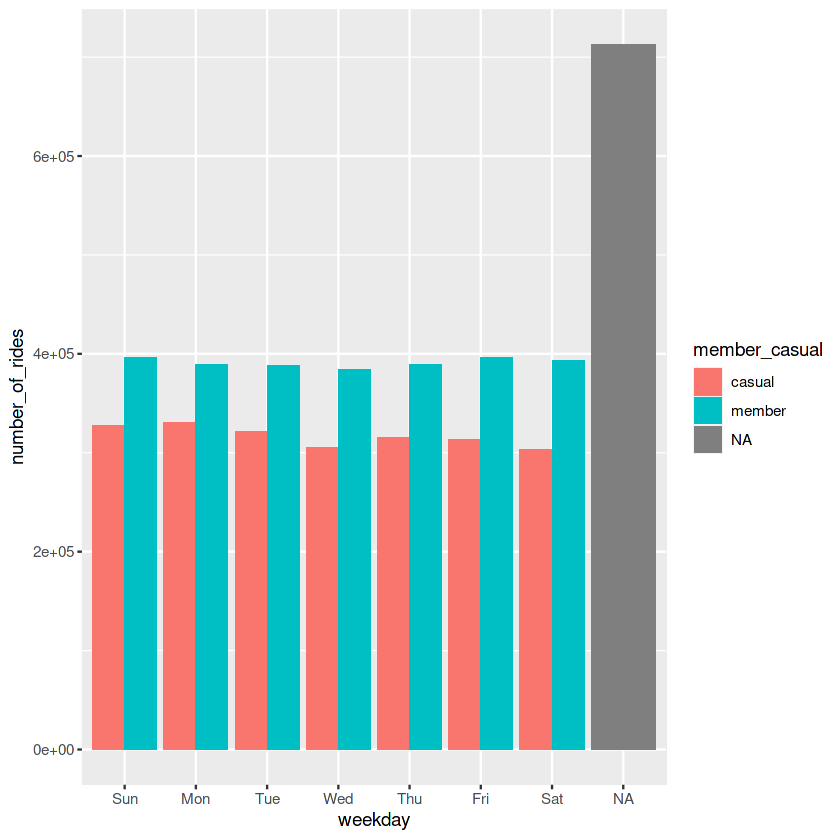

In [24]:
all_trips_v2 %>% 
  mutate(weekday = wday(started_at, label = TRUE)) %>% 
  group_by(member_casual, weekday) %>% 
  summarise(number_of_rides = n()
            ,average_duration = mean(ride_length)) %>% 
  arrange(member_casual, weekday)  %>% 
  ggplot(aes(x = weekday, y = number_of_rides, fill = member_casual)) +
  geom_col(position = "dodge")

Let's create a visualization for average duration

`summarise()` has grouped output by 'member_casual'. You can override using the `.groups` argument.

Warning message:
“Removed 1 rows containing missing values (geom_col).”


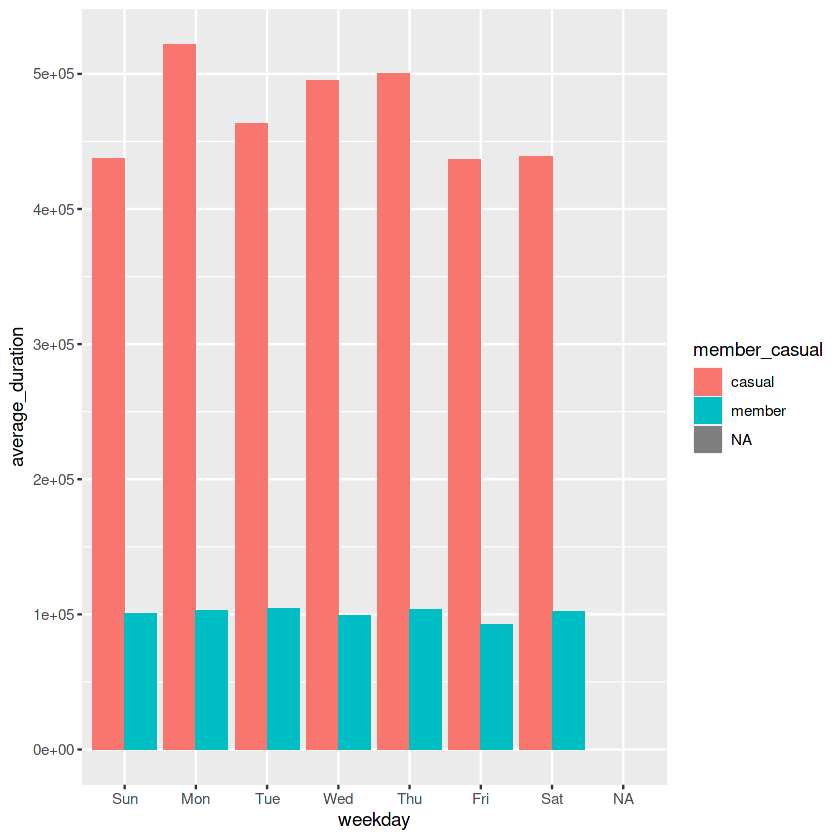

In [25]:

all_trips_v2 %>% 
  mutate(weekday = wday(started_at, label = TRUE)) %>% 
  group_by(member_casual, weekday) %>% 
  summarise(number_of_rides = n()
            ,average_duration = mean(ride_length)) %>% 
  arrange(member_casual, weekday)  %>% 
  ggplot(aes(x = weekday, y = average_duration, fill = member_casual)) +
  geom_col(position = "dodge")